In [1]:
# import the fragment_C_Hole_Measurements.csv file and plot the data
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"

import jax
import jax.numpy as jnp
key = jax.random.key(1234)

import corner
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS


numpyro.set_host_device_count(12)

print(jax.devices())


[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]


In [4]:
# read the data from the csv file

data = pd.read_csv('dataverse_files/1-Fragment_C_Hole_Measurements.csv')

In [5]:
data

,Section ID,Hole,Inter-hole Distance,Mean(X),Mean(Y)
0,0,1,NaN,15.59931,92.59653
1,1,2,NaN,16.44167,91.50069
2,1,3,1.440694,17.30764,90.34931
3,1,4,1.456973,18.15278,89.16250
4,1,5,1.299821,18.96528,88.14792
...,...,...,...,...,...
76,7,77,1.259985,108.69444,63.42778
77,7,78,1.430105,110.05486,63.86875
78,7,79,1.179606,111.14583,64.31736
79,7,80,1.428043,112.48021,64.82604


In [6]:
data.describe()

,Section ID,Hole,Inter-hole Distance,Mean(X),Mean(Y)
count,81.000000,81.000000,74.000000,81.000000,81.000000
mean,2.765432,41.000000,1.365023,61.455655,67.344916
std,1.690204,23.526581,0.127190,29.778150,9.901871
min,0.000000,1.000000,1.051062,15.599310,58.336800
25%,1.000000,21.000000,1.264972,35.109380,59.594790
50%,3.000000,41.000000,1.389709,59.726390,62.990970
75%,3.000000,61.000000,1.447388,86.902780,72.885420
max,7.000000,81.000000,1.651650,113.640280,92.596530


In [7]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Section ID           81 non-null     int64  
 1   Hole                 81 non-null     int64  
 2   Inter-hole Distance  74 non-null     float64
 3   Mean(X)              81 non-null     float64
 4   Mean(Y)              81 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 3.3 KB


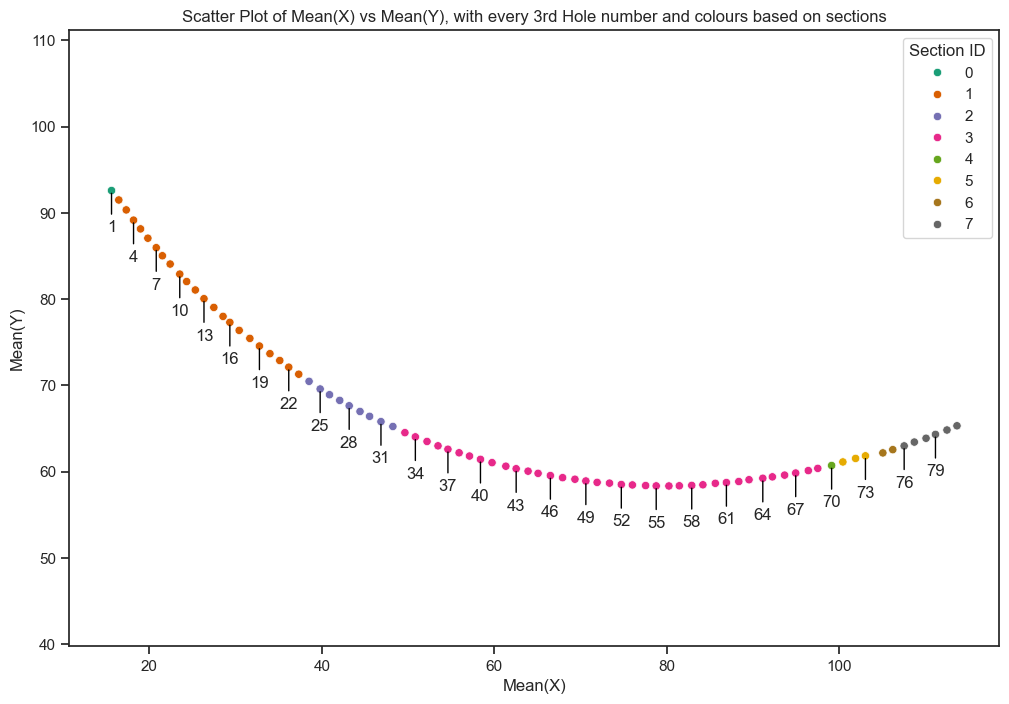

In [8]:
# plot points with x =Mean(X) and y = Mean(Y), number the points with their Hole and colour the points based on their section ID

plt.figure(figsize=(12, 8))  # Make the plot bigger
sns.set(style='ticks')

# Use a bright color palette
palette = sns.color_palette(palette='Dark2')

# Create the scatter plot
scatter_plot = sns.scatterplot(data=data, x='Mean(X)', y='Mean(Y)', hue='Section ID', palette=palette)

# Annotate each point with its hole number
for i in range(data.shape[0]):
    if i % 3 == 0:
        plt.annotate(
            data['Hole'].iloc[i], 
            (data['Mean(X)'].iloc[i], data['Mean(Y)'].iloc[i]), 
            textcoords="offset points", 
            xytext=(0, -30),  # Offset the label below the point
            ha='center', 
            arrowprops=dict(arrowstyle='-', color='black')
        )
# Set the y-axis to start from 50
plt.ylim(55, None)

# Force the x and y scales to be the same
plt.axis('equal')

# Add a title to the plot
plt.title('Scatter Plot of Mean(X) vs Mean(Y), with every 3rd Hole number and colours based on sections')

plt.show()



In [9]:


# drop section ID and inter-hole distance columns
all_section_data = data.drop(columns='Inter-hole Distance')

all_section_data

,Section ID,Hole,Mean(X),Mean(Y)
0,0,1,15.59931,92.59653
1,1,2,16.44167,91.50069
2,1,3,17.30764,90.34931
3,1,4,18.15278,89.16250
4,1,5,18.96528,88.14792
...,...,...,...,...
76,7,77,108.69444,63.42778
77,7,78,110.05486,63.86875
78,7,79,111.14583,64.31736
79,7,80,112.48021,64.82604


# Build model for the hole locations

$$
\hat{m}_i = \hat{r}_{ij} + \hat{r}_{0j} \\
           = |r_{ij}| \cdot (\cos \Phi_{ij},\ \sin \Phi_{ij}) + \hat{r}_{0j} \\
           = |r_{ij}| \cdot (\cos (2 \pi \frac{i - 1}{N} + \alpha_j) ,\ \sin (2 \pi \frac{i - 1}{N} + \alpha_j)) + \hat{r}_{0j}
$$

## for the isotropic Cov matrix it suffices to have sigma**2 * indentity

## for the radial and tangential Cov matrix, in polar coordinates we have 

$$ Cov = [[\sigma_r^2,0], [0,\sigma_t^2]]  $$

$$Cov_{cartesian} = J \ Cov_{polar} \ J^T     $$

where 

$$ J = [[cos(\theta),-r*sin(\theta )],[sin(\theta),r *cos(\theta)]]$$

$$ Cov_{cartesian} = [[ \sigma_r^2cos^⁡2θ \ + \ \sigma_t^2r^2sin^⁡2θ, \ \ (\sigma_r^2−\sigma_t^2r^2)cos⁡θsin⁡θ],\ \ [    (\sigma_r^2 − \ \sigma_t^2r^2)\ cos⁡θsin⁡θ,  \ \ \sigma_r^2sin^⁡2θ \ + \ \sigma_t^2r^2cos^⁡2θ]]  $$

In [10]:

# Filter out Section 0 and Section 4
filtered_data = all_section_data[~all_section_data['Section ID'].isin([0, 4])].copy()

# Reset row indices to be contiguous
filtered_data.reset_index(drop=True, inplace=True)


In [11]:
filtered_data

,Section ID,Hole,Mean(X),Mean(Y)
0,1,2,16.44167,91.50069
1,1,3,17.30764,90.34931
2,1,4,18.15278,89.16250
3,1,5,18.96528,88.14792
4,1,6,19.81389,87.06875
...,...,...,...,...
74,7,77,108.69444,63.42778
75,7,78,110.05486,63.86875
76,7,79,111.14583,64.31736
77,7,80,112.48021,64.82604


In [12]:
print(filtered_data.to_string())

    Section ID  Hole    Mean(X)   Mean(Y)
0            1     2   16.44167  91.50069
1            1     3   17.30764  90.34931
2            1     4   18.15278  89.16250
3            1     5   18.96528  88.14792
4            1     6   19.81389  87.06875
5            1     7   20.78611  85.96875
6            1     8   21.49722  85.03403
7            1     9   22.39931  84.07222
8            1    10   23.51250  82.90486
9            1    11   24.31250  82.04375
10           1    12   25.31736  81.06458
11           1    13   26.32083  80.05486
12           1    14   27.46389  79.04167
13           1    15   28.53125  78.00208
14           1    16   29.32083  77.30833
15           1    17   30.40278  76.37986
16           1    18   31.64028  75.44930
17           1    19   32.75069  74.56528
18           1    20   33.96945  73.67847
19           1    21   35.10938  72.88542
20           1    22   36.15139  72.11111
21           1    23   37.30972  71.29653
22           2    24   38.50764  7

In [13]:
# Define the predicted position function
def predicted_position(i, r, Phi_ij, x0j, y0j):
    
    m_x_i = r * jnp.cos(Phi_ij) + x0j
    m_y_i = r * jnp.sin(Phi_ij) + y0j
    return m_x_i, m_y_i

# Define the covariance function
def iso_cov(sigma, r, theta):
    cos_theta = jnp.cos(theta)
    sin_theta = jnp.sin(theta)
    cos_theta_sq = cos_theta ** 2
    sin_theta_sq = sin_theta ** 2
    cos_theta_sin_theta = cos_theta * sin_theta

    cov_11 = sigma**2 * cos_theta_sq + sigma**2 * r**2 * sin_theta_sq
    cov_12 = (sigma**2 - sigma**2 * r**2) * cos_theta_sin_theta
    cov_21 = cov_12
    cov_22 = sigma**2 * sin_theta_sq + sigma**2 * r**2 * cos_theta_sq

    
    # Stack into a batch of 2x2 covariance matrices
    return jnp.stack([
        jnp.stack([cov_11, cov_12], axis=-1),
        jnp.stack([cov_21, cov_22], axis=-1)
    ], axis=-2)  # Shape: (len(theta), 2, 2)


def phi_calc(i, N, alpha_j):
    phi = 2 * jnp.pi * (i - 1) / N + alpha_j
    return phi


def model(x, y, section_id, hole_id):
    # Priors for parameters
    r = numpyro.sample('r', dist.Uniform(76.5, 78))
    N = numpyro.sample('N', dist.Uniform(351, 359))
    sigma = numpyro.sample('sigma', dist.Uniform(0.01, 0.1))  # Avoid sigma=0
    
    # Initialize category-specific parameters
    x0j = {}
    y0j = {}
    alpha_j = {}

    # Category-specific parameters
    x0j[1] = numpyro.sample('x01', dist.Normal(81, 2))
    x0j[2] = numpyro.sample('x02', dist.Normal(81, 2))
    x0j[3] = numpyro.sample('x03', dist.Normal(81, 2))
    
    x0j[5] = numpyro.sample('x05', dist.Normal(81, 2))
    x0j[6] = numpyro.sample('x06', dist.Normal(81, 2))
    x0j[7] = numpyro.sample('x07', dist.Normal(81, 2))
                         
    y0j[1] = numpyro.sample('y01', dist.Normal(135, 2))
    y0j[2] = numpyro.sample('y02', dist.Normal(135, 2))
    y0j[3] = numpyro.sample('y03', dist.Normal(135, 2))
                         
    y0j[5] = numpyro.sample('y05', dist.Normal(135, 2))
    y0j[6] = numpyro.sample('y06', dist.Normal(135, 2))
    y0j[7] = numpyro.sample('y07', dist.Normal(135, 2))
                         
    alpha_j[1] = numpyro.sample('alpha_1', dist.Uniform(-2.8, -1.7 / 2))
    alpha_j[2] = numpyro.sample('alpha_2', dist.Uniform(-2.8, -1.7 / 2))
    alpha_j[3] = numpyro.sample('alpha_3', dist.Uniform(-2.8, -1.7 / 2))

    alpha_j[5] = numpyro.sample('alpha_5', dist.Uniform(-2.8, -1.7 / 2))
    alpha_j[6] = numpyro.sample('alpha_6', dist.Uniform(-2.8, -1.7 / 2))
    alpha_j[7] = numpyro.sample('alpha_7', dist.Uniform(-2.8, -1.7 / 2))


    # Calculate phi for each hole based on its section
    phi = jnp.array([phi_calc(h, N, alpha_j[s]) for h, s in zip(hole_id, section_id)])  # Use hole index (i) and section-specific alpha_j

    # # Predicted positions based on phi
    # m_x, m_y = jnp.array([predicted_position(h, r, p, x0j[s], y0j[s]) for h, p, s in zip(hole_id, phi, section_id)])
    
    # Predicted positions based on phi
    m_x = jnp.array([predicted_position(h, r, p, x0j[s], y0j[s])[0] for h, p, s in zip(hole_id, phi, section_id)])
    m_y = jnp.array([predicted_position(h, r, p, x0j[s], y0j[s])[1] for h, p, s in zip(hole_id, phi, section_id)])


    # Covariance matrices for each point
    Cov = iso_cov(sigma, r, phi) + jnp.eye(2) * 1e-6


    # Observed positions modeled as multivariate normal
    with numpyro.plate("data", len(x)):   
        numpyro.sample("obs", dist.MultivariateNormal(loc=jnp.stack([m_x, m_y], axis=-1), covariance_matrix=Cov), obs=jnp.stack([x, y], axis=-1))
   


In [14]:
test_phi_1 = phi_calc(91, 360, -jnp.pi/2)
test_phi_2 = phi_calc(181, 360, -jnp.pi/2)
test_phi_3 = phi_calc(46, 360, -jnp.pi/2)

print(test_phi_1, test_phi_2, test_phi_3)


0.0 1.5707963267948966 -0.7853981633974483


  0%|          | 0/11000 [00:00<?, ?it/s]

  0%|          | 0/11000 [00:00<?, ?it/s]

  0%|          | 0/11000 [00:00<?, ?it/s]

  0%|          | 0/11000 [00:00<?, ?it/s]

  0%|          | 0/11000 [00:00<?, ?it/s]

  0%|          | 0/11000 [00:00<?, ?it/s]

  0%|          | 0/11000 [00:00<?, ?it/s]

  0%|          | 0/11000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         N    354.12      1.87    353.76    351.92    357.07       nan 103427.77
   alpha_1     -1.37      0.83     -0.87     -2.80     -0.85       nan 6580241.00
   alpha_2     -0.92      0.12     -0.86     -1.24     -0.85       nan 1016947.31
   alpha_3     -1.07      0.49     -0.87     -2.38     -0.86       nan 4571321.50
   alpha_5     -1.64      0.20     -1.61     -2.09     -1.33      4.00  59050.26
   alpha_6     -1.79      0.19     -1.68     -2.13     -1.62       nan  24245.56
   alpha_7     -1.76      0.06     -1.77     -1.87     -1.66       nan   1117.12
         r     77.02      0.43     76.84     76.58     77.81       nan  72850.23
     sigma      0.10      0.00      0.10      0.09      0.10       nan 375612.78
       x01      0.96      5.49     -0.27     -4.55     14.05       nan 7410541.00
       x02     -0.73      1.19     -0.60     -3.36      0.99       nan 333612.75
       x03     -0.57   

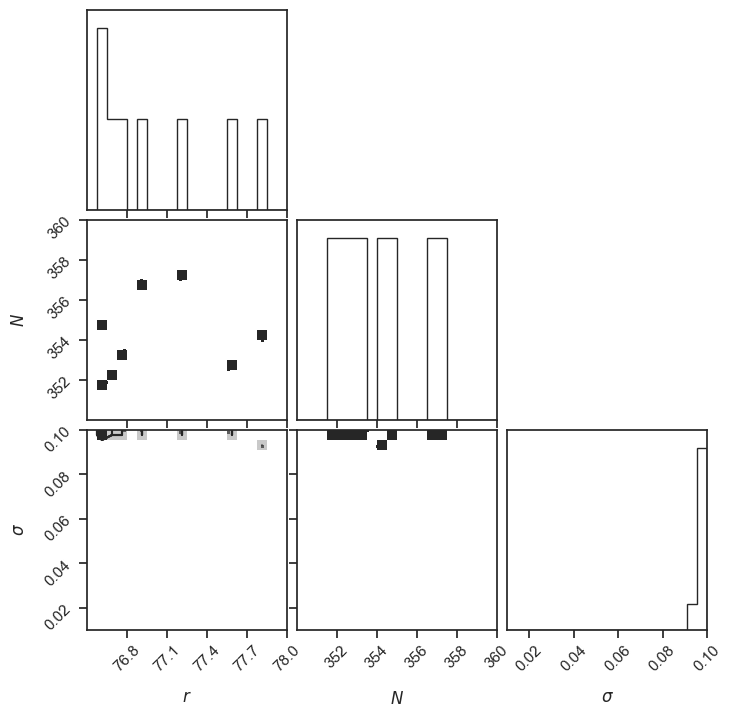

In [17]:
from numpyro.diagnostics import print_summary

# Extract filtered data for use in the model
x = filtered_data['Mean(X)'].values
y = filtered_data['Mean(Y)'].values
section_id = filtered_data['Section ID'].values  # Updated section IDs
hole_id = filtered_data['Hole'].values

# Render the model
numpyro.render_model(model, model_args=(x, y, section_id, hole_id))


# Run MCMC
nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=10000, num_chains=8)
mcmc.run(jax.random.PRNGKey(0), x, y, section_id=section_id, hole_id=hole_id)

# Print quick summary
mcmc.print_summary()

samples = mcmc.get_samples()


# Plot the samples using corner
corner.corner(np.array(jnp.vstack((samples['r'], 
                                   samples['N'],
                                #    samples['x0j'],
                                #    samples['y0j'],
                                #    samples['alpha_j'],
                                   samples['sigma'])).T),
              labels=[r'$r$', r'$N$',  r'$\sigma$'],
              range=[(76.5, 78), (350, 360), (0.01, 0.1)]                     
            #   labels=[r'$r$', r'$N$', r'$x0j$', r'$y0j$', r'$\alpha_j$', r'$\sigma$'],
            #   range=[(76.5, 78), (350, 360), (77, 83), (132, 138), (-2.3, -1.7), (0.005, 0.05)]
              )
plt.show()